### 内容审核：Agent 实现
基于大模型推理出的结果决定，接下来的步骤应该怎么走

{'content': 'zhengzhizhengzhi', 'analysis': '\n\n{\n    "has_issues": true,\n    "issues": ["政治敏感"],\n    "severity": "medium",\n    "confidence": 0.95\n}', 'decision': 'needs_review', 'reason': "内容包含重复的'政治'词汇，可能涉及政治敏感话题但缺乏具体上下文", 'confidence': 0.95}


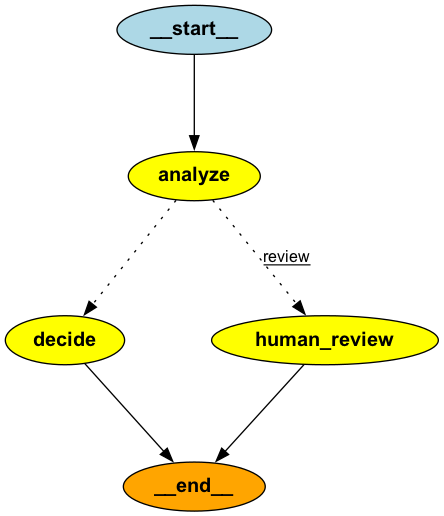

In [2]:
from typing import TypedDict, Literal

from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import json
import os

from langgraph.constants import START, END
from langgraph.graph import StateGraph

load_dotenv()
API_KEY = os.getenv('SILICON_API_KEY')

llm = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider='openai',
    base_url = "https://api.siliconflow.cn/v1",
    api_key = API_KEY,
    temperature=0.0
)

class AgentModerationState(TypedDict):
  content: str
  analysis: str
  decision: str  # "approved" | "rejected" | "needs_review"
  reason: str
  confidence: float


def analyze_content(state: AgentModerationState) -> dict:
  """使用 LLM 分析内容 """
  content = state["content"]
  systemt_prompt = """你是一个内容审核助手。分析给定的内容，判断是否包含：
    1. 不当语言（脏话、侮辱）
    2. 垃圾信息（广告、刷屏）
    3. 敏感话题（政治、暴力、色情）

    请以 JSON 格式返回：
    {
        "has_issues": true/false,
        "issues": ["issue1","issue2"],
        "severity": "low/medium/high",
        "confidence": 0.0-1.0
    }
  """

  message = [
      SystemMessage(content=systemt_prompt),
      HumanMessage(content=f"内容：{content}")
  ]
  response = llm.invoke(message)

  return {"analysis": response.content}


def should_auto_decide(state: AgentModerationState) -> Literal["decide", "human_review"]:
  """根据分析结果决定是否需要人工"""
  # 这里可以添加更复杂的逻辑
  if "high" in state.get("analysis", "").lower():
    return "review"

  return "decide"


def make_agent_decision(state: AgentModerationState) -> dict:
  analysis = state["analysis"]
  content = state["content"]

  system_prompt = """基于之前的分析结果，做出审核决策：
  - approved: 内容正常，通过
  - rejected: 明显违规，直接拒绝
  - needs_review: 需要人工审核

  返回 JSON 格式：
  {
      "decision": "approved/rejected/needs_review",
      "reason": "简短说明",
      "confidence": 0.0-1.0
  }

  """

  message = [
      SystemMessage(content=system_prompt),
      HumanMessage(content=f"原内容 {content}\n\n分析结果：{analysis}")
  ]
  response = llm.invoke(message)


  try:
    result=json.loads(response.content)
    return {
        "decision": result["decision"],
        "reason": result["reason"],
        "confidence": result["confidence"]
    }
  except:
    #解析失败
    return {
        "decision": "needs_review",
        "reason": "已转人工审核",
        "confidence": "1.0"
    }


def human_review_placeholder(state: AgentModerationState)->dict:
  """人工审核占位符（实际应用会中断等待人工）"""
  return {
      "decision": "needs_review",
      "reason": "已转人工审核",
      "confidence": 1.0
  }

# 构建 Agent Graph
agent_graph = StateGraph(AgentModerationState)
agent_graph.add_node("analyze", analyze_content)
agent_graph.add_node("decide", make_agent_decision)
agent_graph.add_node("human_review", human_review_placeholder)

agent_graph.add_edge(START, "analyze")
agent_graph.add_conditional_edges(
    "analyze",
    should_auto_decide,
    {
        "decide": "decide",
        "review": "human_review"
    }
)
agent_graph.add_edge("decide", END)
agent_graph.add_edge("human_review", END)

agent_app = agent_graph.compile()
result = agent_app.invoke({"content":"zhengzhizhengzhi"})
print(result)

# 打印图
from IPython.display import Image, display
try:
  display(Image(agent_app.get_graph(xray=True).draw_png()))
except Exception as e:
    print(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(agent_app.get_graph(xray=True).draw_mermaid())

In [4]:
# === 测试 ===
test_contents = [
    "这个内容很有趣",
    "这个内容很有趣，值得推荐",
    "包含脏话1的内容"
]

print("\n=== Agent 实现结果 ===\n")
for content in test_contents:
    result = agent_app.invoke({"content": content})
    print(f"内容: {content}")
    print(f"分析: {result.get('analysis', 'N/A')[:100]}...")
    print(f"决策: {result['decision']}")
    print(f"原因: {result['reason']}")
    print(f"置信度: {result.get('confidence', 'N/A')}\n")


=== Agent 实现结果 ===

内容: 这个内容很有趣
分析: 

{
    "has_issues": false,
    "issues": [],
    "severity": "low",
    "confidence": 0.9
}...
决策: approved
原因: 没有发现违规内容
置信度: 0.9

内容: 这个内容很有趣，值得推荐
分析: 

{
    "has_issues": false,
    "issues": [],
    "severity": "low",
    "confidence": 0.95
}...
决策: approved
原因: 内容积极正面，无违规信息
置信度: 0.95

内容: 包含脏话1的内容
分析: 

{
    "has_issues": true,
    "issues": ["不当语言"],
    "severity": "high",
    "confidence": 0.8
}...
决策: needs_review
原因: 已转人工审核
置信度: 1.0

